**Problem 1 (a)** Write a function that returns one realisation of Z. It should take as arguments
the cell’s division rate ρ, the cell’s mutation rate µ, and the time interval T.

In [95]:
## calculate number of divisions

import numpy as np                 # import numpy for Poisson distribution
rng = np.random.default_rng()      # Set random numbers

def numberofdivisions(time_interval, division_rate):    # create function to calculate total number of divisions
    D = rng.poisson(lam=division_rate * time_interval)  # generate random Poisson integer using division rate and time interval parameters
    return(D)                                           # store D inside the function to retrieve later
Divisions = numberofdivisions(1, 1)                     # Rename D to Divisions and store function output as variable so it can be printed and reused in second mutation function
print("Total Number of Divisions:", Divisions)          # print output of function

## calculate number of mutations using number of divisions

def numberofmutations(mutation_rate, Divisions):        # create a second function to calculate total number of mutations
    Z = 0                                               # start counter (Z) at 0
    for i in range(Divisions):                          # for value of Divisions function, do the following;
        M = rng.poisson(lam=mutation_rate)              # generate a random number of mutations from Poisson distribution
        Z += M                                          # add this number of mutations M to Z 
    return(Z)                                           # store Z inside function as the function output
Mutations = numberofmutations(1, Divisions)             # store mutation function as variable that can be printed and used outside of function
print("Total Number of Mutations:", Mutations)          # print the total number of mutations

Total Number of Divisions: 0
Total Number of Mutations: 0


**Problem 1 (b)** (b) Using the parameters ρ = 2 (divisions per day), µ = 20 (mutations per division),
and T = 50 (days), obtain 500 realisations of Z. Plot these in a histogram. 

Number of Divisions for 500 realisations: [103, 89, 88, 108, 89, 92, 95, 101, 101, 89, 106, 100, 108, 96, 104, 92, 91, 98, 98, 106, 102, 107, 107, 99, 85, 86, 94, 94, 106, 104, 108, 94, 95, 92, 98, 106, 93, 126, 85, 90, 95, 97, 108, 94, 115, 102, 99, 97, 102, 98, 100, 102, 109, 109, 104, 106, 102, 107, 106, 90, 85, 105, 103, 115, 85, 89, 108, 90, 89, 92, 105, 113, 109, 67, 93, 110, 107, 94, 103, 91, 97, 116, 95, 105, 118, 84, 115, 90, 90, 100, 95, 107, 111, 89, 106, 103, 101, 81, 104, 104, 119, 108, 105, 109, 88, 97, 88, 98, 81, 106, 99, 100, 89, 113, 108, 108, 93, 78, 106, 88, 103, 98, 99, 93, 99, 109, 97, 114, 118, 100, 90, 112, 96, 91, 109, 89, 102, 116, 92, 96, 96, 104, 107, 105, 104, 100, 105, 99, 97, 100, 101, 101, 111, 79, 119, 100, 86, 111, 82, 92, 97, 105, 93, 97, 102, 100, 101, 105, 95, 114, 82, 100, 91, 97, 87, 98, 102, 103, 106, 92, 118, 106, 96, 98, 107, 106, 99, 101, 109, 102, 101, 99, 98, 107, 88, 92, 114, 123, 95, 110, 99, 98, 95, 111, 104, 113, 99, 122, 99, 93, 103, 11

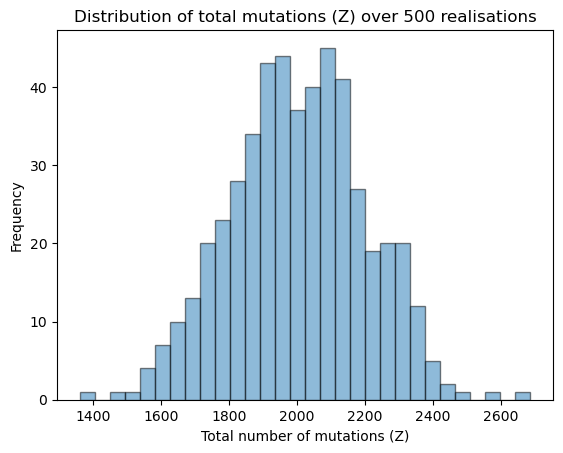

In [120]:
# create a wrapper function for one_realisation
def one_realisation(time_interval, division_rate, mutation_rate):    # wrap both functions into a giant function that allows you to feed in parameter values as a whole function
    D = numberofdivisions(division_rate, time_interval)              # name D as a variable 
    Z = numberofmutations(mutation_rate, D)                          # name Z as a variable
    return(D, Z)                                                     # return D and Z so they can be called outside the function

# repeat one_realisation realisation 500 times
Divisions500 = []                           # make an empty list to store values for divisions after 500 realisations
Mutations500 = []                           # make an empty list to store values for mutations after 500 realisations
for i in range(500):                        # use a range tool to repeat one_realisation 500 times
    D, Z = one_realisation(50, 2, 20)       # input parameter values into one_realisation function as listed in question
    Divisions500.append(D)                  # once D has ran 500 times, add each value to Divisions500 list
    Mutations500.append(Z)                  # once Z has ran 500 times, add each value to Mutations500 list
print("Number of Divisions for 500 realisations:", Divisions500)      # print list output for each set of divisions per realisation for 500 realisations
print("Number of Mutations for 500 realisations:", Mutations500)      # print list output for each set of mutations per realisation for 500 realisations

# plot histogram of mutations for 500 realisations
import matplotlib.pyplot as plt     # import matplotlib

plt.hist(Mutations500, bins=30, alpha=0.5, edgecolor='black')  # generate histogram with 30 bins, line width 0.5 and bin edge colour black

# Add labels and title
plt.xlabel('Total number of mutations (Z)')   # add x axis label
plt.ylabel('Frequency')                       # add y axis label
plt.title('Distribution of total mutations (Z) over 500 realisations')     # add graph title
plt.show()                                                                 # show histogram



**Problem 1 (c)** Create a new function that takes the same arguments as the previously defined
function, and returns the mean of 500 realisations of Z. Use this function to plot
how the mean of Z varies with the time interval T.
TIP: you can use the numpy function numpy.linspace(start,stop,num) to generate num equidistantly spaced values between start and stop.

In [125]:
# create a wrapper function for one_realisation
def one_realisation(time_interval, division_rate, mutation_rate):    # wrap both functions into a giant function that allows you to feed in parameter values as a whole function
    D = numberofdivisions(division_rate, time_interval)              # name D as a variable 
    Z = numberofmutations(mutation_rate, D)                          # name Z as a variable
    return(D, Z)                                                     # return D and Z so they can be called outside the function

# repeat one_realisation realisation 500 times                        # make an empty list to store values for divisions after 500 realisations
Mutations500 = []                           # make an empty list to store values for mutations after 500 realisations
for i in range(500):                        # use a range tool to repeat one_realisation 500 times
    D, Z = one_realisation(50, 2, 20)       # input parameter values into one_realisation function as listed in question
    Mutations500.append(Z)                  # once Z has ran 500 times, add each value to Mutations500 list
meanofZ = sum(Mutations500)/len(Mutations500)    # calculate mean of Z over 500 realisations
meanofZ   # call mean of Z
################################################ review not asnwered q

## alter not the number of experiments (500), but the number of days ran each experiment for. - not sure where numpy.linspace(start,stop,num) comes into this tho/

1987.138

In [ ]:
numpy.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None, axis=0)
